In [ ]:
import numpy as np
import tensorflow as tf
import random
import os

# function for setting seed 
def set_seeds(seed=42):
    # setting seed for python interpreter
    os.environ['PYTHONHASHSEED'] = str(seed)
    # seeding the python random lib 
    random.seed(seed)
    # seeding numpy 
    np.random.seed(seed)
    # seeding tensorflow
    tf.random.set_seed(seed)
    # for prioritizing consistency over performance (better for reproducibility)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

# calling func
set_seeds(42)

## **feature extraction**

In [ ]:
# importing relevant packages for this portion
import librosa
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.utils import to_categorical

# defining genre buster extraction 
def extract_genre_buster_features(audio, sr, segment_duration=3):
    '''
    audio = raw data
    sr = sample rate (data points per sec of audio)
    segment_duration = defines how to break up songs 
        default is 3 --> so 3 sec chunks
    '''
    # calculating how many data points are in 3 sec of audio
    samples_per_seg = sr * segment_duration
    # calculating how many 3 sec segments are in the audio file
    num_segments = len(audio) // samples_per_seg

    # initializing list to store features of audio
    all_features = []

    # normalizing audio (scales volume so loudest is 1.0)
        # helps to clarify if one song is recorded super loud vs quiet
    audio = librosa.util.normalize(audio)
    
    # estimating beat per minute 
    tempo, _ = librosa.beat.beat_track(y=audio, sr=sr)
    # ensuring that it becomes an array
    tempo_val = np.atleast_1d(tempo)
    

    # LOOPING THRU EVERY 3 SEC CHUNK! 
    for i in range(num_segments):
        start = i * samples_per_seg
        finish = start + samples_per_seg
        seg = audio[start:finish]
        
        # looking at TIMBRE
        mfcc = librosa.feature.mfcc(y=seg, sr=sr, n_mfcc=40) # mfcc looks at shape of sound (what type of sound it is)
        # deltas look at how the mfcc changes throughout the segment
            # first is velocity
        delta = librosa.feature.delta(mfcc)
        # second is acceleration
        delta2 = librosa.feature.delta(mfcc, order=2)
        
        # looking at HARMONY
            # chroma func maps audio into semitones 
                # complex chords vs simple ones 
        chroma = librosa.feature.chroma_stft(y=seg, sr=sr)
        
        # looking at ENERGY
        # centroid looks at mass of sound 
            # high = bright/high pitch, low = bass/lower
        centroid = librosa.feature.spectral_centroid(y=seg, sr=sr)
        rms = librosa.feature.rms(y=seg) # RMS of average loudness
        # zero crossing looks at how often waves go pos/neg or neg/pos
        zcr = librosa.feature.zero_crossing_rate(seg)

        # looks at differences in audio (like what is clear sounding versus unclear)
        spec_con = librosa.feature.spectral_contrast(y=seg, sr=sr)
        # looks whether audio is vocal heavy or bass heavy
        rolloff = librosa.feature.spectral_rolloff(y=seg, sr=sr, roll_percent=0.85)
        # looking at width of sound
        bandwidth = librosa.feature.spectral_bandwidth(y=seg, sr=sr)
        # tone vs noise 
        flatness = librosa.feature.spectral_flatness(y=seg)
        
        
        # combining all the stuff above into one vector 
            # mean or std of features from above since points change over 3 sec of audio
        combined = np.hstack([
            np.mean(mfcc, axis=1), np.std(mfcc, axis=1),
            np.mean(delta, axis=1), np.std(delta, axis=1),
            np.mean(delta2, axis=1), np.std(delta2, axis=1),
            np.mean(chroma, axis=1), 
            np.mean(centroid, axis=1), 
            np.mean(rms, axis=1),     
            np.mean(zcr, axis=1), 
            np.mean(spec_con, axis=1), 
            np.mean(rolloff, axis=1), 
            np.mean(bandwidth, axis=1), 
            np.mean(flatness, axis=1),
            tempo_val    
        ])
        all_features.append(combined)
        
    return all_features

## **getting data, prepping, train and test**

In [ ]:
def process_directory(path):
    # initialzing 
        # X for features, y for genre, names for file name
    X, y, names = [], [], []
    # going thru everything in path 
    for genre in os.listdir(path):
        # directory plus genre name (which is folder name)
        genre_path = os.path.join(path, genre)
        # making sure not getting other weird files in folder
        if not os.path.isdir(genre_path): continue

        # looping through each file in genre folder
        for file in os.listdir(genre_path):
            # looking only for audio files
            if file.lower().endswith((".wav", ".mp3", ".m4a")):
                try:
                    # reading in audio file, keep sample rate
                    audio, sr = librosa.load(os.path.join(genre_path, file), sr=None)
                    # calling func on audio and sr
                    segments = extract_genre_buster_features(audio, sr)
                    # append all info to initialized vars
                    for seg in segments:
                        X.append(seg)
                        y.append(genre)
                        names.append(file)
                # for debugging
                except Exception as e:
                    print(f"did not read {file}: {e}")
    return np.array(X), np.array(y), names


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_45538/1356062876.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(os.path.join(genre_path, file), sr=None)
/Users/sophiekim/miniforge3/envs/climate_env/lib/python3.10/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Skipping jazz.00054.wav: 


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_45538/1356062876.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(os.path.join(genre_path, file), sr=None)
/Users/sophiekim/miniforge3/envs/climate_env/lib/python3.10/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [ ]:
# loading GTZAN data from sophie directory 
X_train_raw, y_train_raw, train_song_names = process_directory("/Users/sophiekim/Desktop/1_spring/ds 6050/Data/genres_original")
# loading in real world songs
X_test_raw, y_test_raw, test_song_names = process_directory("/Users/sophiekim/Desktop/1_spring/ds 6050/genres_new")

from sklearn.model_selection import train_test_split

# looking at every unique song rather than looking at each 3 sec segment
    # helps with model not memorizing GTZAN data since 3 sec of same song could go in train and test 
unique_song_filenames = np.unique(train_song_names)

# splitting train and val sets on the unique song names 
train_songs, val_songs = train_test_split(
    unique_song_filenames, 
    test_size=0.2, 
    random_state=42
)


# making. masks to ensure that all segments of one song are in either train or val 
train_mask = np.isin(train_song_names, train_songs)
val_mask = np.isin(train_song_names, val_songs)

# using masks to filter X and y sets to the right full songs 
X_train = X_train_raw[train_mask]
y_train = y_train_raw[train_mask]
X_val = X_train_raw[val_mask]
y_val = y_train_raw[val_mask]

# encoding 
    # converting text to number
encoder = LabelEncoder()
# one-hot encoding the numbers for both sets
y_train_enc = to_categorical(encoder.fit_transform(y_train))
y_val_enc = to_categorical(encoder.transform(y_val))

# centering so mean is 1 and std is 0
scaler = StandardScaler()
# only fit_transform on training data so that only train set is seen by model (prevent info leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_raw)

## **train with class weights**

In [ ]:
# making sure we chill 
np.unique(y_train_raw)

array(['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz',
       'metal', 'pop', 'reggae', 'rock'], dtype='<U9')

In [ ]:
from sklearn.utils import class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# adding weights to features so that higher weight gets to more rare genres
weights = class_weight.compute_class_weight(
    'balanced', 
    classes=np.unique(y_train_raw), 
    y=y_train_raw
)
# adding this to a dict
class_weights_dict = dict(enumerate(weights))

# forcing model to add more weight to pop and classical music specifically
    # model couldn't differentiate for these genres especially
class_weights_dict[8] *= 2.0  
class_weights_dict[2] *= 2.0



from tensorflow.keras import regularizers

model = Sequential([
    # dense layer of 1024 neurons, using L2 to punish model for larger weights (avoid overfitting)
    Dense(1024, activation='relu', input_shape=(X_train_scaled.shape[1],), 
          kernel_regularizer=regularizers.l2(0.001)), 
    # rescaling data 
    BatchNormalization(), 
    # dropping 30% of neurons to prevent overfitting to train set
    Dropout(0.3), 
    # etc..
    Dense(512, activation='relu', 
          kernel_regularizer=regularizers.l2(0.001)), 
    BatchNormalization(), 
    Dropout(0.5), 

    Dense(256, activation='relu'), 
    BatchNormalization(), 
    # number of neurons = number of genres, softmax to get probabilities of genres
    Dense(len(encoder.classes_), activation='softmax')
])

# categorical cross entropy bc multi class classification
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary

# defining early stopping 
early_stop = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
# reducing LR if model gets stuck on loss, reducing LR by 80%, trying to prevent plateau that model lands on
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=7, min_lr=0.00001)

history = model.fit(
    X_train_scaled, 
    y_train_enc, 
    epochs=500, 
    batch_size=32, 
    validation_data=(X_val_scaled, y_val_enc), 
    class_weight=class_weights_dict,          
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

/Users/sophiekim/miniforge3/envs/climate_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-16 08:32:57.331964: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-04-16 08:32:57.332136: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-16 08:32:57.332152: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-16 08:32:57.332345: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-16 08:32:57.332365: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_facto

Epoch 1/500


2026-04-16 08:32:58.507417: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.5406 - loss: 2.6016 - val_accuracy: 0.5956 - val_loss: 2.0652 - learning_rate: 0.0010
Epoch 2/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.6390 - loss: 1.9563 - val_accuracy: 0.6306 - val_loss: 1.6755 - learning_rate: 0.0010
Epoch 3/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.6612 - loss: 1.6545 - val_accuracy: 0.6426 - val_loss: 1.4628 - learning_rate: 0.0010
Epoch 4/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.6747 - loss: 1.5100 - val_accuracy: 0.6466 - val_loss: 1.3729 - learning_rate: 0.0010
Epoch 5/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.6675 - loss: 1.4340 - val_accuracy: 0.6426 - val_loss: 1.3393 - learning_rate: 0.0010
Epoch 6/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.6744 - loss: 1.4123 - val_accuracy: 0.6386 - val_loss: 1.3350 - learning_rate: 0.0010
Epoch 7/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.6767 - loss: 1.4086

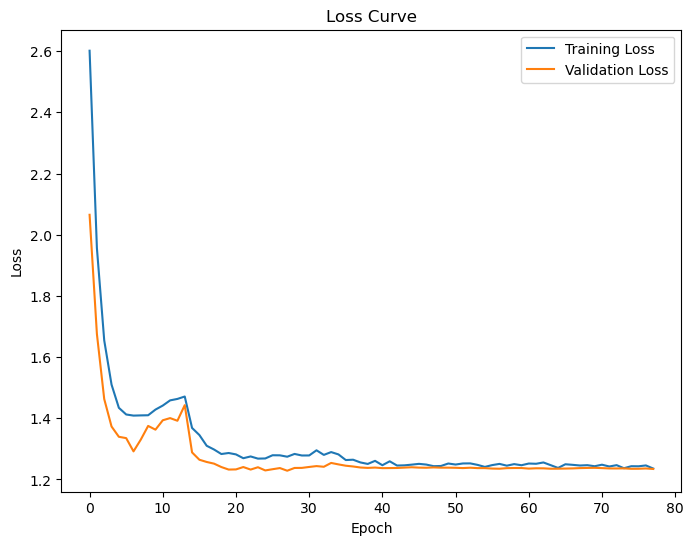

In [ ]:
# looking at loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# looking at final val accuracy
final_val_acc = history.history['val_accuracy'][-1]
print(f"Final Validation Accuracy: {final_val_acc * 100:.2f}%")

Final Validation Accuracy: 68.37%


## **test accuracy on real songs**

In [ ]:
# looking at predictions for every song segment, picking index of highest prob
preds = np.argmax(model.predict(X_test_scaled), axis=1)
# converting genres back to text 
pred_genres = encoder.inverse_transform(preds)

# MAJORITY VOTING
# making df for all the diff song segments
results = pd.DataFrame({'song': test_song_names, 'true': y_test_raw, 'pred': pred_genres})
# grouping all the segments from one song together
    # 'true': 'first' gets genre of first segment's song
    # lambda function for counting what genre was predicted most for that song and picks mode 
final_votes = results.groupby('song').agg({'true': 'first', 'pred': lambda x: x.value_counts().index[0]})

# comparing true genre to pred genre to get accuracy 
song_acc = (final_votes['true'] == final_votes['pred']).mean()
print(f"Final Per-Song Accuracy: {song_acc * 100:.2f}%")

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
Final Per-Song Accuracy: 41.00%


## **confusion matrix**

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Total Unique Songs Found: 100
--- SUCCESS ---
Overall Song-Level Accuracy: 41.00%


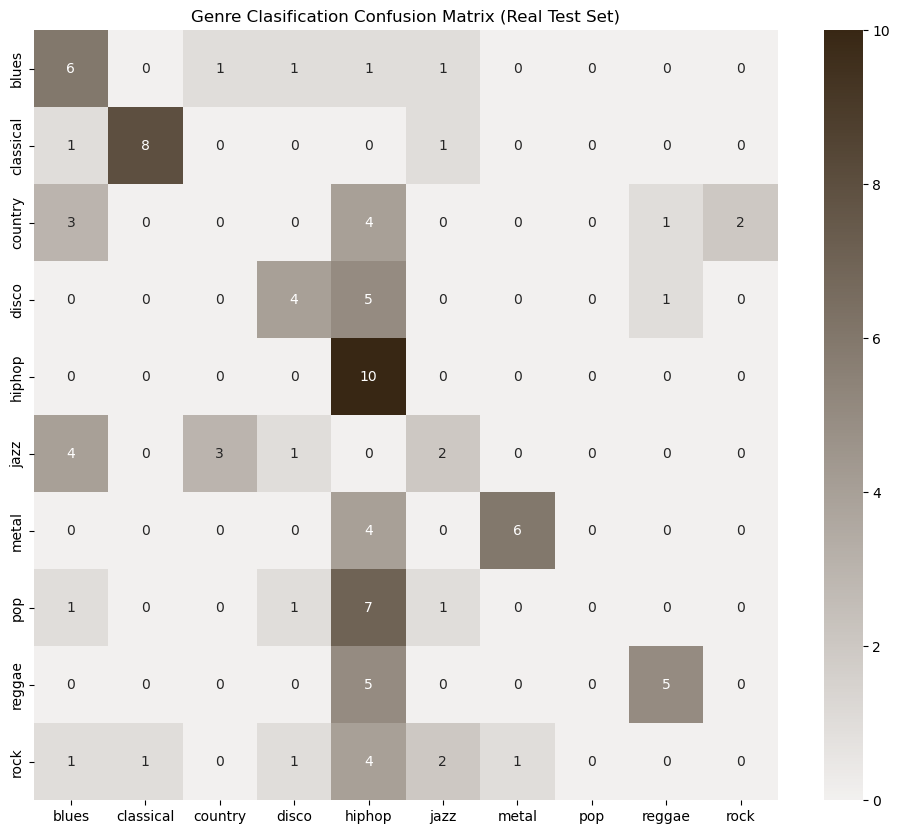

In [ ]:

from scipy.stats import mode
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# making sure everything 1d array
names_flat = np.array(test_song_names).flatten()
y_test_flat = np.array(y_test_raw).flatten()

# getting predictions from X test
y_pred_probs = model.predict(X_test_scaled)
# getting index of highest probability 
y_pred_segments = np.argmax(y_pred_probs, axis=1)

# intiailizing 
song_predictions = []
song_actuals = []


# getting unique song names from the name array, collapse segments into one entry per song
unique_songs = sorted(list(set(names_flat)))

# making sure all the songs are there (100)
print(f"Total Unique Songs Found: {len(unique_songs)}")

# looping through each song 
for song in unique_songs:
    # find index of the current song in the name file 
    indices = [i for i, x in enumerate(names_flat) if x == song]
    # going through every index (aka segment row) for the song 
    if indices:
        # segment preds
        current_song_preds = y_pred_segments[indices]
        
        # counting amount of times genre was pred 
        vals, counts = np.unique(current_song_preds, return_counts=True)
        # getting mode of that 
        final_vote = vals[np.argmax(counts)]
        # adding to list
        song_predictions.append(final_vote)
        
        # getting actual values 
            # getting the actual genre from the first song segment (since genre the same for all)
        actual_genre = y_test_flat[indices[0]]
        # converting the text to numeric 
        actual_label = encoder.transform([actual_genre])[0]
        song_actuals.append(actual_label)

# if length of list has stuff
if len(song_predictions) > 0:
    # getting overall song accuracy 
    overall_acc = accuracy_score(song_actuals, song_predictions)
    print(f"Overall Song-Level Accuracy: {overall_acc * 100:.2f}%")
    
    # making confusion matrix 
    cm = confusion_matrix(song_actuals, song_predictions)
    cmap = sns.light_palette("#382714", as_cmap=True)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=encoder.classes_, 
                yticklabels=encoder.classes_)
    plt.title('Genre Clasification Confusion Matrix (Real Test Set)')
    plt.show()
else:
    print("uh oh")

## **looking at per genre accuracy**

In [ ]:
# making df with true vals and predicted vals 
results = pd.DataFrame({
    "true": y_test_raw,
    "pred": pred_genres
})

# making correct column 0/1 to see where preds were right
results["is_correct"] = (results["true"] == results["pred"])

# getting accuracy per genre by averaging binary correct col 
genre_acc = results.groupby("true")["is_correct"].mean()

print(genre_acc.sort_values(ascending=False))

--- Accuracy Per Genre ---
true
hiphop       0.990000
metal        0.660000
classical    0.655556
reggae       0.530000
blues        0.455556
disco        0.350000
jazz         0.211111
country      0.052632
rock         0.020000
pop          0.000000
Name: is_correct, dtype: float64


## **saving preds in csv**

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import mode

# getting preds 
y_pred_probs = model.predict(X_test_scaled)
# converting preds to integer index 
pred_labels_segments = np.argmax(y_pred_probs, axis=1)

# cleaning up by making everything strings and getting rid of whitespace
names_list = [str(name).strip() for name in test_song_names]
labels_list = [str(label).strip() for label in y_test_raw]

# making unique song list 
unique_songs = []
for name in names_list:
    if name not in unique_songs:
        unique_songs.append(name)

song_results = []

# compiling 
for song in unique_songs:
    # finding indices for every segment that belongs to unique song
    indices = [i for i, x in enumerate(names_list) if x == song]
    
    # if got some locations
    if indices:
        # get where preds for that song are 
        current_preds = pred_labels_segments[indices]
        
        # getting count of genre occurence
        vals, counts = np.unique(current_preds, return_counts=True)
        # getting most popular genre
        final_vote_idx = vals[np.argmax(counts)]
        # making genre number to text
        predicted_genre = encoder.inverse_transform([final_vote_idx])[0]
        
        # getting correct genre of song from first segment of song 
        actual_genre = labels_list[indices[0]]
        
        # adding everything together 
        song_results.append({
            'Song_Name': song,
            'Actual_Genre': actual_genre,
            'Predicted_Genre': predicted_genre,
            'Correct_Flag': 1 if str(actual_genre) == str(predicted_genre) else 0
        })

# making df 
df_compiled = pd.DataFrame(song_results)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
DEBUG: Processing 100 unique songs...
--- SUCCESS ---
Generated 100 rows in 'compiled_song_predictions.csv'
Overall Song-Level Accuracy: 41.00%


## **bar plot for comparing genre pred performance for audio vs image models**

In [65]:
import pandas as pd 


audio_preds = pd.read_csv("/Users/sophiekim/Desktop/1_spring/ds 6050/genres_new/compiled_song_predictions.csv")
image_preds = pd.read_csv("/Users/sophiekim/Desktop/1_spring/ds 6050/image_test_predictions.csv")

In [ ]:

# go thru every row in song name col and gets only the first 'element' of the song name (like ignore .jpg)
audio_preds['join_key'] = audio_preds['Song_Name'].apply(lambda x: os.path.splitext(x)[0])
image_preds['join_key'] = image_preds['File_Name'].apply(lambda x: os.path.splitext(x)[0])

# merge on join key col 
df_combined = pd.merge(audio_preds, image_preds, on='join_key', how='left')

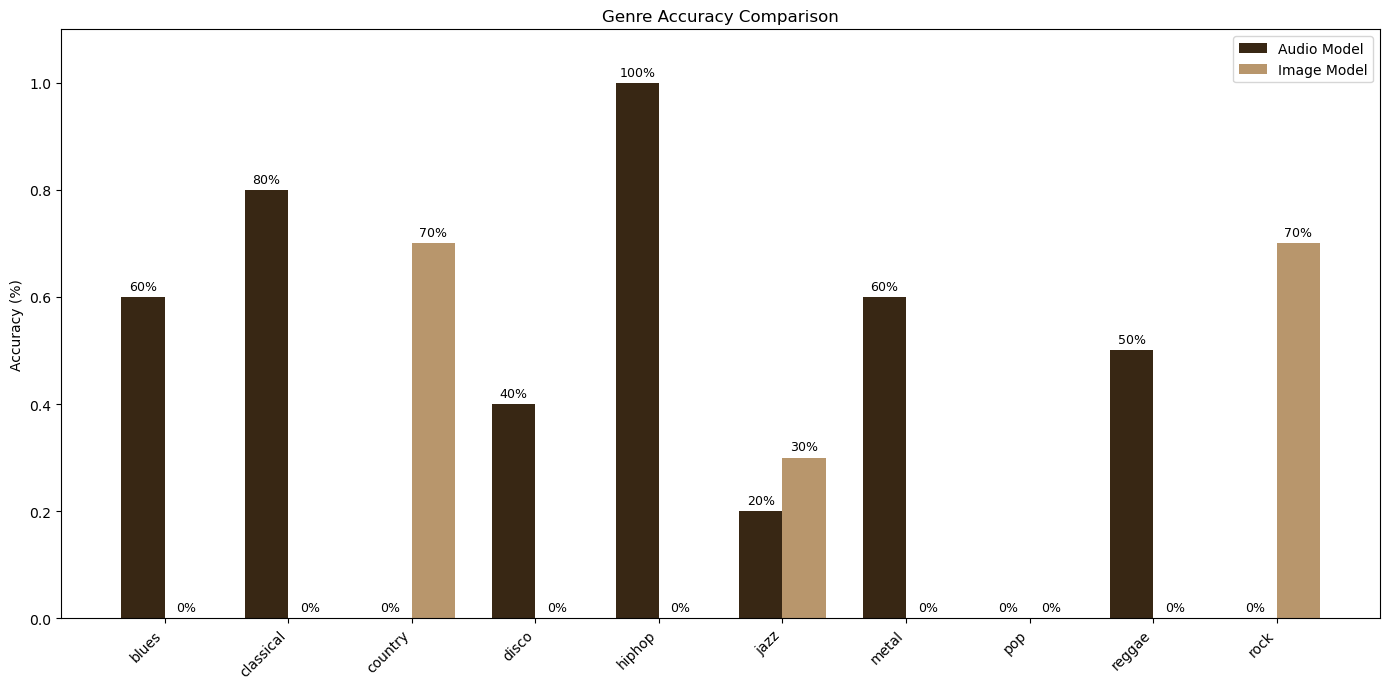

In [ ]:


# renaming correct flag from audio csv to audio correct 
df_combined = df_combined.rename(columns={'Correct_Flag': 'Audio_Correct'})
# making a correct 0/1 col for image model 
df_combined['Image_Correct'] = (df_combined['True_Class'] == df_combined['Predicted_Class']).astype(int)


# calculating accuracy per genre for both models 
genre_acc = df_combined.groupby('Actual_Genre').agg({
    'Audio_Correct': 'mean',
    'Image_Correct': 'mean'
}).sort_index()

# getting unique genre value indices
genres = genre_acc.index
# how far x axis should go 
x = np.arange(len(genres)) 
width = 0.35               
fig, ax = plt.subplots(figsize=(14, 7))

# making bars 
rects1 = ax.bar(x - width/2, genre_acc['Audio_Correct'], width, label='Audio Model', color='#382714') 
rects2 = ax.bar(x + width/2, genre_acc['Image_Correct'], width, label='Image Model', color='#b8966c') 


ax.set_ylabel('Accuracy (%)')
ax.set_title('Genre Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(genres, rotation=45, ha='right')
ax.set_ylim(0, 1.1) 
ax.legend()

# adding accuracy labels on top of bars 
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if not np.isnan(height):
            ax.annotate(f'{height:.0%}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()